# Fit a model to the canopy height training data


## Import libraries

In [1]:
from joblib import dump
import shap
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sb
from scipy.stats import gaussian_kde
import lightgbm as lgb
import matplotlib.pyplot as plt
from dea_tools.classification import sklearn_flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

from sklearn.model_selection import ShuffleSplit, KFold, RandomizedSearchCV

from dualpol_indices import dualpol_indices

## Import training data

In [2]:
df = pd.read_csv('CH_combined_training_data.csv')
df = df.drop('Unnamed: 0', axis=1)

In [3]:
x_vars = list(df.columns)
x_vars.remove('canopy_height')

In [4]:
X = df[x_vars].values
y = df['canopy_height'].values

## Nested cross validation

In [5]:
inner_cv_splits = 5

outer_cv_splits = 5

test_size = 0.20

In [6]:
# Create the parameter grid based on the results of random search
param_grid = {
    'num_leaves': stats.randint(5,25),
    'min_child_samples':stats.randint(5,20),
    'boosting_type': ['gbdt', 'dart'],
    'max_depth': stats.randint(5,25),
    'n_estimators': [300, 400, 500],
}

In [7]:
outer_cv = KFold(n_splits=outer_cv_splits, shuffle=True,
                        random_state=0)

# lists to store results of CV testing
r2_all = []
rmse_all = []
pred_ = []
i = 1

for train_index, test_index in outer_cv.split(X, y):
    print(f"Working on {i}/{outer_cv_splits} outer CV split", end='\r')
    model = lgb.LGBMRegressor(random_state=1, verbose=-1)

    # Index training, testing, and coordinate data
    X_tr, X_tt = X[train_index, :], X[test_index, :]
    y_tr, y_tt = y[train_index], y[test_index]
    
    # Inner split on data within outer split
    inner_cv = KFold(n_splits=inner_cv_splits,
                     shuffle=True,
                     random_state=0)
    
    clf = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=50,
        refit=True,
        verbose=0,
        cv=inner_cv.split(X_tr, y_tr)
    )

    clf.fit(X_tr, y_tr)
    
    # Predict using the best model
    best_model = clf.best_estimator_
    pred = best_model.predict(X_tt)

    r2=r2_score(y_tt, pred)
    rmse=root_mean_squared_error(y_tt, pred)

    r2_all.append(r2)
    rmse_all.append(rmse)

    #1:1 plots for each fold (save to csv so we can make a plot later on)
    df = pd.DataFrame({'Test':y_tt, 'Pred':pred}).reset_index(drop=True)

    pred_.append(df)
        
    i += 1

cross_df = pd.concat(pred_)

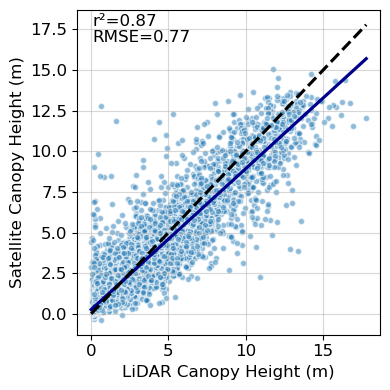

In [8]:
fig,ax = plt.subplots(1,1, figsize=(4,4))

sb.scatterplot(data=cross_df, x='Test',y='Pred', s=20, lw=1, alpha=0.5, ax=ax)
sb.regplot(data=cross_df, x='Test',y='Pred', scatter=False, color='darkblue', ax=ax)
sb.regplot(data=cross_df, x='Test',y='Test', color='black', scatter=False, line_kws={'linestyle':'dashed'}, ax=ax)
# plt.colorbar()
plt.xlabel('LiDAR Canopy Height (m)', fontsize=12)
plt.ylabel('Satellite Canopy Height (m)', fontsize=12)
ax.text(.05, .95, 'r\N{SUPERSCRIPT TWO}={:.2f}'.format(np.mean(r2_all)),
            transform=ax.transAxes, fontsize=12)
ax.text(.05, .9, 'RMSE={:.2g}'.format(np.mean(rmse_all)),
            transform=ax.transAxes, fontsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(alpha=0.5)
plt.tight_layout();


## Fit a final model

In [9]:
outer_cv = KFold(n_splits=5, shuffle=True,
                   random_state=0)

clf = RandomizedSearchCV(
    lgb.LGBMRegressor(verbose=-1, random_state=1),
    param_grid,
    verbose=1,
    n_iter=250,
    cv=outer_cv
)

clf.fit(X, y, callbacks=None)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


/env/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
                   estimator=LGBMRegressor(random_state=1, verbose=-1),
                   n_iter=250,
                   param_distributions={'boosting_type': ['gbdt', 'dart'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fc33bfa6950>,
                                        'min_child_samples': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fc33bfa59c0>,
                                        'n_estimators': [300, 400, 500],
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fc33bfa5c30>},
                   verbose=1)

In [10]:
from pprint import pprint
print("The most accurate combination of tested parameters is: ")
pprint(clf.best_params_)
print('\n')
print("The best score using these parameters is: ")
print(round(clf.best_score_, 2))

The most accurate combination of tested parameters is: 
{'boosting_type': 'gbdt',
 'max_depth': 19,
 'min_child_samples': 15,
 'n_estimators': 500,
 'num_leaves': 23}


The best score using these parameters is: 
0.87


In [11]:
model = lgb.LGBMRegressor(**clf.best_params_)

model.fit(X,y)

LGBMRegressor(max_depth=19, min_child_samples=15, n_estimators=500,
              num_leaves=23)

## Save model

In [12]:
dump(model, f'test_chm_model.joblib')

['results/test_chm_model.joblib']